# Prediksi Harga Emas dengan TFT dan Random Forest

## Update Versi:
- **Menambahkan Random Forest Regressor** sebagai algoritma perbandingan

## Algoritma yang Dibandingkan:
1. **TFT (Temporal Fusion Transformer)** - Deep Learning dengan Attention Mechanism
2. **Random Forest Regressor** - Machine Learning klasik dengan Ensemble Learning

In [ ]:
# ==============================================================================
# 1. INSTALASI LIBRARY
# ==============================================================================
!pip uninstall -y lightning pytorch-lightning pytorch-forecasting

!pip install pytorch-forecasting \
             "pytorch-lightning==2.2.0" \
             "lightning==2.2.0" \
             pandas \
             numpy \
             matplotlib \
             optuna \
             scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.3/800.3 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.8/399.8 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.1 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
     

In [ ]:
# ==============================================================================
# 2. UPLOAD DATASET
# ==============================================================================
import pandas as pd
import io
from google.colab import files

print("-> Upload 'gold_price_merged.csv'...")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
with open('gold_price_merged.csv', 'wb') as f:
    f.write(uploaded[file_name])
print(f"   ✅ {file_name} ({len(pd.read_csv(io.BytesIO(uploaded[file_name])))} baris)")

-> Upload 'gold_price_merged.csv'...


Saving gold_price_merged_with_idr.csv to gold_price_merged_with_idr.csv
   ✅ gold_price_merged_with_idr.csv (1324 baris)


In [ ]:
# ==============================================================================
# 3. IMPORT LIBRARY
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import optuna
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, QuantileLoss
from pytorch_forecasting.data import EncoderNormalizer
from unittest.mock import patch
import warnings, random
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import pickle

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
pl.seed_everything(SEED)

print("✅ Libraries imported successfully")

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


✅ Libraries imported successfully


In [ ]:
# ==============================================================================
# 4. PREPROCESSING
# ==============================================================================
print("\n-> Memuat dan memproses dataset...")
df = pd.read_csv('gold_price_merged.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Fill missing values
ffill_cols = [
    'oil_dcoilwtico', 'fed_rate_pct', 'fed_target_rate_from_pct',
    'fed_target_rate_to_pct', 'cpi_cpiaucsl',
    'usd_open', 'usd_close', 'usd_adj_close',
    'gspc_open', 'gspc_close',
]
for col in ffill_cols:
    if col in df.columns:
        df[col] = df[col].ffill().bfill()

# Feature Engineering
df['close_lag1']  = df['close'].shift(1)
df['close_lag5']  = df['close'].shift(5)
df['close_ma7']   = df['close'].rolling(7).mean()
df['close_ma20']  = df['close'].rolling(20).mean()
df['close_std7']  = df['close'].rolling(7).std()

df['log_close']   = np.log(df['close'])
df['log_close_lag1'] = df['log_close'].shift(1)
df['log_close_ma7']  = df['log_close'].rolling(7).mean()

df['close_pct_from_ma20'] = (df['close'] - df['close_ma20']) / df['close_ma20']

df['gold_ret1']   = df['close'].pct_change()
df['gold_ret5']   = df['close'].pct_change(5)
df['usd_ret1']    = df['usd_close'].pct_change()
df['gspc_ret1']   = df['gspc_close'].pct_change()
df['oil_ret1']    = df['oil_dcoilwtico'].pct_change()

df['usd_close_lag1']  = df['usd_close'].shift(1)
df['oil_lag1']        = df['oil_dcoilwtico'].shift(1)
df['gspc_close_lag1'] = df['gspc_close'].shift(1)

df['gold_vol5']   = df['gold_ret1'].rolling(5).std()
df['gold_vol20']  = df['gold_ret1'].rolling(20).std()

# Drop NaN
required_cols = [
    'close_lag1', 'close_lag5', 'close_ma7', 'close_ma20', 'close_std7',
    'log_close', 'log_close_lag1', 'log_close_ma7', 'close_pct_from_ma20',
    'gold_ret1', 'gold_ret5', 'usd_ret1', 'gspc_ret1',  'oil_ret1',
    'usd_close_lag1', 'oil_lag1', 'gspc_close_lag1', 
    'gold_vol5', 'gold_vol20',
]
df = df.dropna(subset=required_cols).reset_index(drop=True)

# Metadata
df['time_idx']    = range(len(df))
df['group_id']    = 'XAU_USD'
df['day_of_week'] = df['date'].dt.day_name().astype(str)
df['month']       = df['date'].dt.month.astype(str)
df['year_num']    = (df['date'].dt.year - 2021).astype(float)

print(f"   Total data      : {len(df)} baris")
print(f"   Rentang tanggal : {df['date'].min().date()} s/d {df['date'].max().date()}")
print(f"   Close range     : ${df['close'].min():.0f} – ${df['close'].max():.0f}")


-> Memuat dan memproses dataset...
   Total data      : 1304 baris
   Rentang tanggal : 2021-02-01 s/d 2026-02-18
   Close range     : $1622 – $5418


In [ ]:
# ==============================================================================
# 5. DATASET DEFINITION (TFT)
# ==============================================================================
max_prediction_length = 7
max_encoder_length    = 60
training_cutoff = int(len(df) * 0.80) - 1

print(f"\n-> Membangun TimeSeriesDataSet untuk TFT...")

unknown_reals = [
    "open", "close", "tickvol",
    "close_lag1", "close_lag5", "close_ma7", "close_ma20", "close_std7",
    "log_close", "log_close_lag1", "log_close_ma7",
    "close_pct_from_ma20",
    "gold_ret1", "gold_ret5", "gold_vol5", "gold_vol20",
    "usd_open", "usd_close", "usd_adj_close", "usd_close_lag1", "usd_ret1",
    "gspc_open", "gspc_close", "gspc_close_lag1", "gspc_ret1",
    "oil_dcoilwtico", "oil_lag1", "oil_ret1",
    "fed_rate_pct", "fed_target_rate_from_pct", "fed_target_rate_to_pct",
    "cpi_cpiaucsl",
]

training = TimeSeriesDataSet(
    df[df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="close",
    group_ids=["group_id"],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["group_id"],
    time_varying_known_categoricals=["day_of_week", "month"],
    time_varying_known_reals=["time_idx", "year_num"],
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=EncoderNormalizer(
        method="standard",
        center=True,
        transformation=None,
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation_for_training = TimeSeriesDataSet.from_dataset(
    training, df, predict=True, stop_randomization=True
)
validation_for_eval = TimeSeriesDataSet.from_dataset(
    training, df, predict=False, stop_randomization=True
)

batch_size = 64
train_dataloader    = training.to_dataloader(train=True,  batch_size=batch_size, num_workers=2)
val_dataloader      = validation_for_training.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=2)
val_eval_dataloader = validation_for_eval.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=2)

print(f"   Training samples        : {len(training)}")
print(f"   Validation (evaluasi)   : {len(validation_for_eval)}")


-> Membangun TimeSeriesDataSet untuk TFT...
   Training samples        : 1049
   Validation (evaluasi)   : 1310


In [ ]:
# ==============================================================================
# 6. OPTUNA HYPERPARAMETER TUNING (TFT)
# ==============================================================================
print("\n-> Optuna Hyperparameter Tuning untuk TFT (50 trials)...")

def objective(trial: optuna.Trial) -> float:
    learning_rate          = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    hidden_size            = trial.suggest_categorical("hidden_size", [32, 64, 128, 256])
    attention_head_size    = trial.suggest_categorical("attention_head_size", [1, 2, 4])
    dropout                = trial.suggest_float("dropout", 0.05, 0.3)
    hidden_continuous_size = trial.suggest_categorical("hidden_continuous_size", [16, 32, 64])

    if hidden_size % attention_head_size != 0:
        raise optuna.TrialPruned()

    model = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=learning_rate,
        hidden_size=hidden_size,
        attention_head_size=attention_head_size,
        dropout=dropout,
        hidden_continuous_size=hidden_continuous_size,
        loss=QuantileLoss(),
        optimizer="adam",
        log_interval=-1,
        reduce_on_plateau_patience=3,
    )

    early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")
    trainer = pl.Trainer(
        max_epochs=30,
        accelerator="auto",
        enable_model_summary=False,
        enable_progress_bar=False,
        gradient_clip_val=0.1,
        callbacks=[early_stop],
        logger=False,
    )
        trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
        val_loss = trainer.callback_metrics.get("val_loss", float("inf"))
        val_mae = trainer.callback_metrics.get("val_MAE", float("inf"))
        epochs = trainer.current_epoch + 1

        trial.set_user_attr("val_MAE", float(val_mae) if hasattr(val_mae, "item") else float(val_mae))
        trial.set_user_attr("epochs", epochs)

        return float(val_loss.item() if hasattr(val_loss, "item") else float(val_loss))


study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    study_name="TFT_Gold_USD_v2"

)

study.optimize(objective, n_trials=50)

print(f"\n{'='*85}")
print(f" HASIL OPTUNA - TFT (Semua Trial)")
print(f"{'='*85}")
print(f"\n {'Tr':<4} | {'LR':<12} | {'HS':<6} | {'Head':<6} | {'Drop':<8} | {'HCS':<6} | {'Val Loss':<10} | {'MAE':<10} | {'Ep':<5} | {'Status'}")
print(f" {'-'*4} | {'-'*12} | {'-'*6} | {'-'*6} | {'-'*8} | {'-'*6} | {'-'*10} | {'-'*10} | {'-'*5} | {'-'*10}")

for i, trial in enumerate(study.trials):
    status = "PRUNED" if trial.state == optuna.trial.TrialState.PRUNED else "OK"
    if trial.value is not None:
        params = trial.params
        lr = f"{params.get('learning_rate', '-'):.6f}"
        hs = params.get('hidden_size', '-')
        ahs = params.get('attention_head_size', '-')
        dr = f"{params.get('dropout', '-'):.4f}"
        hcs = params.get('hidden_continuous_size', '-')
        vl = f"{trial.value:.4f}"
        mae = f"{trial.user_attrs.get('val_MAE', '-'):.4f}" if 'val_MAE' in trial.user_attrs else "-"
        ep = trial.user_attrs.get('epochs', '-')
        print(f" {i:<4} | {lr:<12} | {hs:<6} | {ahs:<6} | {dr:<8} | {hcs:<6} | {vl:<10} | {mae:<10} | {ep:<5} | {status}")
    else:
        print(f" {i:<4} | {'-':<12} | {'-':<6} | {'-':<6} | {'-':<8} | {'-':<6} | {'-':<10} | {'-':<10} | {'-':<5} | {status}")

print(f"{'-'*85}")
best = study.best_trial
best_mae = best.user_attrs.get('val_MAE', '-')
best_epoch = best.user_attrs.get('epochs', '-')
print(f"\n ✅ PARAMETER TERBAIK (Trial #{best.number})")
print(f"    Val Loss  : {study.best_value:.4f}")
print(f"    Val MAE   : {best_mae:.4f}" if isinstance(best_mae, float) else f"    Val MAE   : {best_mae}")
print(f"    Epochs   : {best_epoch}")
for key, val in study.best_params.items():
    print(f"    {key:<30} = {val}")
print(f"{'='*85}")


-> Optuna Hyperparameter Tuning untuk TFT (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, usin


 HASIL OPTUNA - TFT
 Val Loss Terbaik : 58.9161
   learning_rate                  = 0.007341470215893885
   hidden_size                    = 128
   attention_head_size            = 2
   dropout                        = 0.06310971527338187
   hidden_continuous_size         = 64


In [ ]:
# ==============================================================================
# 7. FINAL TRAINING - TFT MODEL
# ==============================================================================
print("\n-> Melatih Model TFT Final...")
best_params = study.best_params
torch.cuda.empty_cache()

best_tft_model = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate          = best_params["learning_rate"],
    hidden_size            = best_params["hidden_size"],
    attention_head_size    = best_params["attention_head_size"],
    dropout                = best_params["dropout"],
    hidden_continuous_size = best_params["hidden_continuous_size"],
    loss=QuantileLoss(),
    optimizer="adam",
    reduce_on_plateau_patience=5,
    log_interval=10,
)

early_stop_final = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=15, mode="min")
checkpoint_cb    = ModelCheckpoint(
    monitor="val_loss", mode="min", save_top_k=1,
)

final_trainer = pl.Trainer(
    max_epochs=150,
    accelerator="auto",
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[early_stop_final, checkpoint_cb],
)
final_trainer.fit(best_tft_model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores



-> Melatih Model TFT Final...


INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params
----------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0     
1  | logging_metrics                    | ModuleList                      | 0     
2  | input_embeddings                   | MultiEmbedding                  | 93    
3  | prescalers                         | ModuleDict                      | 5.5 K 
4  | static_variable_selection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# Load best TFT model
best_model_path = final_trainer.checkpoint_callback.best_model_path

_orig = torch.load
def _patched(f, map_location=None, **kwargs):
    kwargs['weights_only'] = False
    return _orig(f, map_location=map_location, **kwargs)

with patch('torch.load', _patched):
    best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

print(f"✅ Best TFT model loaded from: {best_model_path}")

✅ Best TFT model loaded from: /content/lightning_logs/version_0/checkpoints/best_tft_no_idr_epoch=21-val_loss=28.7988.ckpt


In [ ]:
# ==============================================================================
# 8. RANDOM FOREST REGRESSOR - MODEL PERBANDINGAN
# ==============================================================================

print("\n" + "="*60)
print(" RANDOM FOREST REGRESSOR - MODEL PERBANDINGAN")
print("="*60)

# ── Fitur untuk RF ─────────────────────────────────────────
rf_features = [
    'close_lag1', 'close_lag5', 'close_ma7', 'close_ma20', 'close_std7',
    'log_close', 'log_close_lag1', 'log_close_ma7',
    'close_pct_from_ma20',
    'gold_ret1', 'gold_ret5', 'gold_vol5', 'gold_vol20',
    'usd_close_lag1', 'usd_ret1',
    'gspc_close_lag1', 'gspc_ret1',
     
    'oil_lag1', 'oil_ret1',
]

# Mapping encode categorical → numeric
day_map = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
    'Friday': 4, 'Saturday': 5, 'Sunday': 6,
}


# ── Dataset builder ─────────────────────────────────────────
def create_rf_dataset(df, features, target='close', window_size=60, forecast_horizon=7):
    X_list, y_list = [], []

    for i in range(window_size, len(df) - forecast_horizon + 1):
        window_data = df[features].iloc[i - window_size:i].values.flatten()
        current_row = df.iloc[i]

        # Encode categorical variables ke numeric
        day_num  = day_map.get(current_row['day_of_week'], 0)  # Monday=0, Sunday=6
        month_num = int(current_row['month'])
        year_num  = float(current_row['year_num'])

        temporal_features = [day_num, month_num, year_num]

        X_row = np.concatenate([window_data, temporal_features])
        y_row = df[target].iloc[i]

        X_list.append(X_row)
        y_list.append(y_row)

    return np.array(X_list), np.array(y_list)


# ── Split train / val ───────────────────────────────────────
X_rf, y_rf = create_rf_dataset(df, rf_features, window_size=max_encoder_length)

train_size = training_cutoff - max_encoder_length + 1

X_train_rf, X_val_rf = X_rf[:train_size], X_rf[train_size:]
y_train_rf, y_val_rf = y_rf[:train_size], y_rf[train_size:]

print(f"   Train size      : {len(X_train_rf)}")
print(f"   Validation size : {len(X_val_rf)}")

# ── Training ────────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=SEED,
    n_jobs=-1,
)

rf_model.fit(X_train_rf, y_train_rf)
print("\n   ✅ Random Forest training selesai!")

# ── Simpan model ────────────────────────────────────────────
    pickle.dump(rf_model, f)




 RANDOM FOREST REGRESSOR - MODEL PERBANDINGAN
   Train size      : 983
   Validation size : 255

   ✅ Random Forest training selesai!
   ✅ Model RF disimpan: rf_no_idr_model.pkl


In [ ]:
# Evaluasi RF
rf_pred_val = rf_model.predict(X_val_rf)

mae_rf_val  = mean_absolute_error(y_val_rf, rf_pred_val)
rmse_rf_val = np.sqrt(mean_squared_error(y_val_rf, rf_pred_val))
mape_rf_val = np.mean(np.abs((y_val_rf - rf_pred_val) / (np.abs(y_val_rf) + 1e-8))) * 100
r2_rf_val   = r2_score(y_val_rf, rf_pred_val)

print(f"\n{'='*60}")
print(f" HASIL EVALUASI - RANDOM FOREST")
print(f"{'='*60}")
print(f" MAE   : {mae_rf_val:>10,.4f}")
print(f" RMSE  : {rmse_rf_val:>10,.4f}")
print(f" MAPE  : {mape_rf_val:>8.2f} %")
print(f" R²    : {r2_rf_val:>8.4f}")
print(f"{'='*60}")


 HASIL EVALUASI - RANDOM FOREST
 MAE   :   894.3403
 RMSE  : 1,064.6214
 MAPE  :    22.58 %
 R²    :  -2.4044


In [ ]:
# ==============================================================================
# 9. EVALUASI TFT MODEL
# ==============================================================================
print("\n-> Evaluasi TFT Model...")

raw_predictions = best_tft.predict(val_eval_dataloader, mode="raw", return_x=True)
predictions_raw = best_tft.predict(val_eval_dataloader, mode="prediction")
actuals         = torch.cat([y[0] for x, y in iter(val_eval_dataloader)])

pred_np   = predictions_raw.cpu().numpy()
actual_np = actuals.cpu().numpy()

flat_actual = actual_np.flatten()
flat_pred   = pred_np.flatten()
valid_mask  = ~(np.isnan(flat_actual) | np.isnan(flat_pred))

flat_actual_clean = flat_actual[valid_mask]
flat_pred_clean   = flat_pred[valid_mask]

mae_tft  = np.mean(np.abs(flat_actual_clean - flat_pred_clean))
mape_tft = np.mean(np.abs((flat_actual_clean - flat_pred_clean) / (np.abs(flat_actual_clean) + 1e-8))) * 100
rmse_tft = np.sqrt(np.mean((flat_actual_clean - flat_pred_clean) ** 2))
r2_tft   = r2_score(flat_actual_clean, flat_pred_clean)

print(f"\n{'='*60}")
print(f" HASIL EVALUASI - TFT MODEL")
print(f"{'='*60}")
print(f" MAE   : {mae_tft:>10,.4f}")
print(f" RMSE  : {rmse_tft:>10,.4f}")
print(f" MAPE  : {mape_tft:>8.2f} %")
print(f" R²    : {r2_tft:>8.4f}")
print(f"{'='*60}")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



-> Evaluasi TFT Model...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



 HASIL EVALUASI - TFT MODEL
 MAE   :    32.8332
 RMSE  :    69.2722
 MAPE  :     1.07 %
 R²    :   0.9936


In [ ]:
# ==============================================================================
# 10. PERBANDINGAN TFT vs RANDOM FOREST
# ==============================================================================
print("\n" + "="*70)
print(f"{'PERBANDINGAN MODEL: TFT vs RANDOM FOREST':^70}")
print("="*70)
print(f"{'Metrik':<15} {'TFT':>15} {'Random Forest':>18} {'Selisih':>15}")
print(f"{'-'*70}")
print(f"{'MAE (USD)':<15} {mae_tft:>15,.4f} {mae_rf_val:>18,.4f} {mae_tft-mae_rf_val:>15,.4f}")
print(f"{'RMSE (USD)':<15} {rmse_tft:>15,.4f} {rmse_rf_val:>18,.4f} {rmse_tft-rmse_rf_val:>15,.4f}")
print(f"{'MAPE (%)':<15} {mape_tft:>15,.2f} {mape_rf_val:>18,.2f} {mape_tft-mape_rf_val:>15,.2f}")
print(f"{'R² Score':<15} {r2_tft:>15,.4f} {r2_rf_val:>18,.4f} {r2_tft-r2_rf_val:>15,.4f}")
print("="*70)

if mae_tft < mae_rf_val:
    print("\n🏆 Model TERBAIK: TFT (Temporal Fusion Transformer)")
else:
    print("\n🏆 Model TERBAIK: Random Forest Regressor")


               PERBANDINGAN MODEL: TFT vs RANDOM FOREST               
Metrik                      TFT      Random Forest         Selisih
----------------------------------------------------------------------
MAE (USD)               32.8332           894.3403       -861.5071
RMSE (USD)              69.2722         1,064.6214       -995.3492
MAPE (%)                   1.07              22.58          -21.51
R² Score                 0.9936            -2.4044          3.3980

🏆 Model TERBAIK: TFT (Temporal Fusion Transformer)


In [ ]:
# ==============================================================================
# 11. VISUALISASI
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# TFT Sample Prediction
best_tft.plot_prediction(raw_predictions.x, raw_predictions.output, idx=0, add_loss_to_title=True, ax=axes[0, 0])
axes[0, 0].set_title("TFT: Sample Prediksi 7-Hari", fontsize=11)

# Perbandingan Metrics
models = ['TFT', 'Random Forest']
maes_comp = [mae_tft, mae_rf_val]
mapes_comp = [mape_tft, mape_rf_val]
r2s_comp = [r2_tft, r2_rf_val]

x_pos = np.arange(len(models))
width = 0.25

axes[0, 1].bar(x_pos - width, maes_comp, width, label='MAE', color='steelblue')
axes[0, 1].bar(x_pos, mapes_comp, width, label='MAPE', color='tomato')
axes[0, 1].bar(x_pos + width, r2s_comp, width, label='R²', color='green')
axes[0, 1].set_title('Perbandingan Metrics')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Actual vs Predicted Scatter
axes[1, 0].scatter(flat_actual_clean, flat_pred_clean, alpha=0.3, s=10, label='TFT', color='steelblue')
axes[1, 0].scatter(y_val_rf, rf_pred_val, alpha=0.3, s=10, label='RF', color='tomato')
axes[1, 0].plot([flat_actual_clean.min(), flat_actual_clean.max()],
                [flat_actual_clean.min(), flat_actual_clean.max()], 'k--', lw=2)
axes[1, 0].set_title('Actual vs Predicted')
axes[1, 0].set_xlabel('Actual (USD)')
axes[1, 0].set_ylabel('Predicted (USD)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Feature Importance RF
feature_importance = pd.DataFrame({
    'Feature': [f'F{i}' for i in range(len(rf_model.feature_importances_))],
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

axes[1, 1].barh(feature_importance['Feature'], feature_importance['Importance'])
axes[1, 1].set_title('RF: Top 15 Feature Importance')
axes[1, 1].set_xlabel('Importance')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_tft_rf.png", dpi=150, bbox_inches='tight')
plt.show()


-> Interpretability TFT...


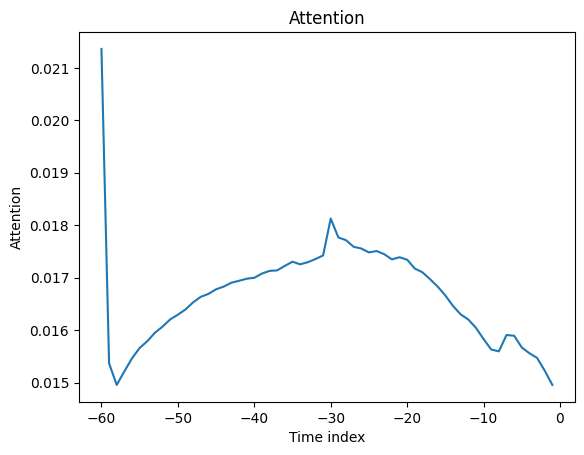

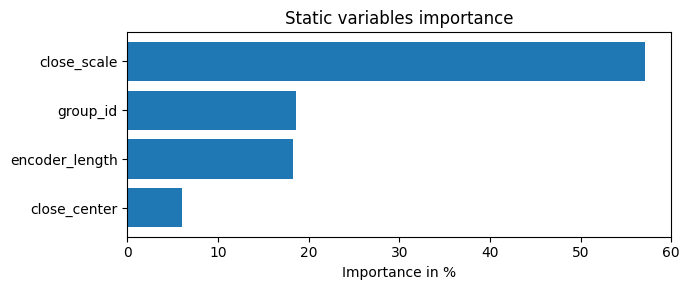

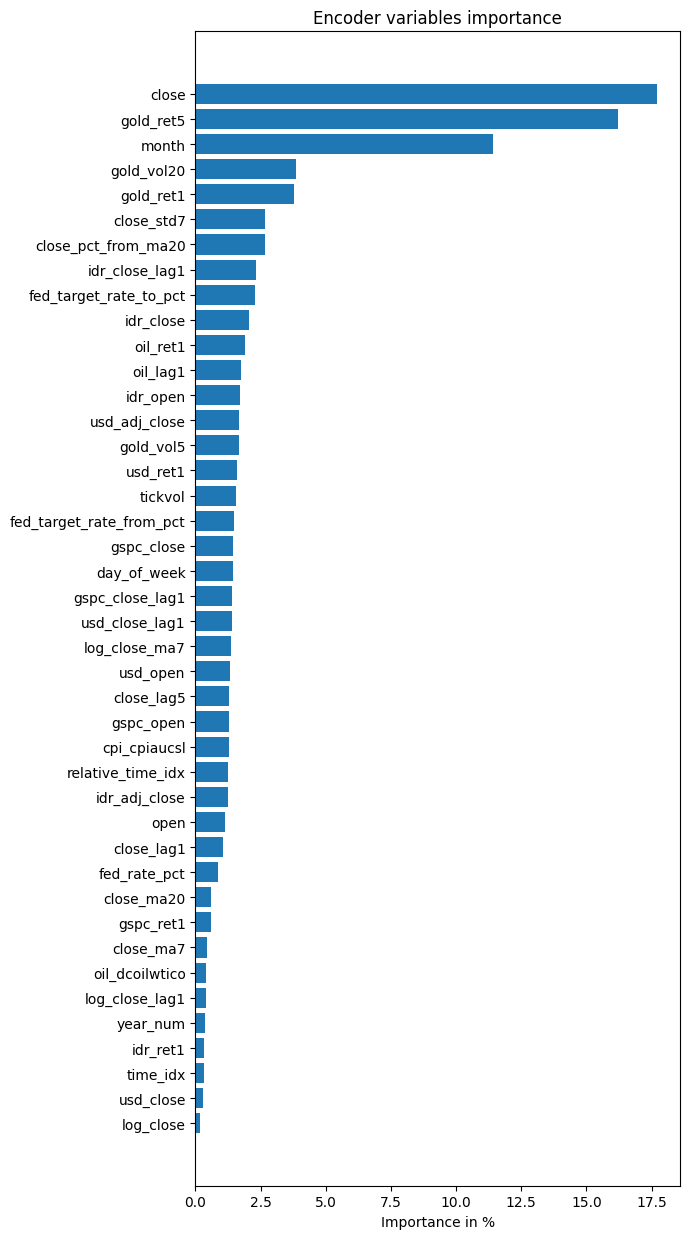

In [ ]:
# ==============================================================================
# 12. INTERPRETABILITY - TFT
# ==============================================================================
print("\n-> Interpretability TFT...")
interpretation = best_tft.interpret_output(raw_predictions.output, reduction="sum")
best_tft.plot_interpretation(interpretation)
plt.suptitle("Interpretability TFT: Pengaruh Variabel (USD/USD)", fontsize=13)
plt.tight_layout()
plt.savefig("tft_interpretability.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ==============================================================================
# 13. PREDIKSI 7 HARI KE DEPAN
# ==============================================================================
print("\n-> Prediksi 7 hari ke depan dari data terakhir...")

last_data    = df.tail(max_encoder_length).copy()
last_date    = df['date'].max()
future_dates = pd.bdate_range(last_date + pd.Timedelta(days=1), periods=max_prediction_length)
future_df    = pd.DataFrame({'date': future_dates})

future_df['group_id']    = 'XAU_USD'
future_df['day_of_week'] = future_df['date'].dt.day_name().astype(str)
future_df['month']       = future_df['date'].dt.month.astype(str)
future_df['year_num']    = (future_df['date'].dt.year - 2021).astype(float)
future_df['time_idx']    = list(range(
    int(df['time_idx'].max()) + 1,
    int(df['time_idx'].max()) + 1 + max_prediction_length
))

for col in df.columns:
    if col not in future_df.columns:
        future_df[col] = df[col].iloc[-1]

for col in unknown_reals:
    future_df[col] = df[col].iloc[-1]

future_df['close'] = df['close'].iloc[-1]

predict_df = pd.concat([last_data, future_df], ignore_index=True)

predict_dataset = TimeSeriesDataSet.from_dataset(
    training, predict_df, predict=True, stop_randomization=True
)
predict_loader = predict_dataset.to_dataloader(train=False, batch_size=1, num_workers=0)
future_preds   = best_tft.predict(predict_loader, mode="prediction")
future_values  = future_preds[0].cpu().numpy().tolist()

print(f"\n{'='*60}")
print(f" PREDIKSI HARGA EMAS 7 HARI KE DEPAN (TFT)")
print(f"{'='*60}")
last_close = df['close'].iloc[-1]
print(f" Harga terakhir ({last_date.date()}): ${last_close:,.2f}")
print(f" {'Tanggal':<15} {'Prediksi TFT':>15} {'Δ dari terakhir':>16}")
print(f" {'-'*60}")
for d, p in zip(future_dates, future_values):
    delta = p - last_close
    sign  = "+" if delta >= 0 else ""
    print(f" {str(d.date()):<15} ${p:>14,.2f} {sign}{delta:>14,.2f}")
print(f"{'='*60}")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



-> Prediksi 7 hari ke depan dari data terakhir...

 PREDIKSI HARGA EMAS 7 HARI KE DEPAN (TFT)
 Harga terakhir (2026-02-18): $4,977.07
 Tanggal            Prediksi TFT  Δ dari terakhir
 ------------------------------------------------------------
 2026-02-19      $      5,044.22 +         67.15
 2026-02-20      $      4,974.41          -2.66
 2026-02-23      $      4,921.25         -55.82
 2026-02-24      $      4,904.57         -72.50
 2026-02-25      $      4,909.58         -67.49
 2026-02-26      $      4,936.57         -40.50
 2026-02-27      $      4,951.52         -25.55


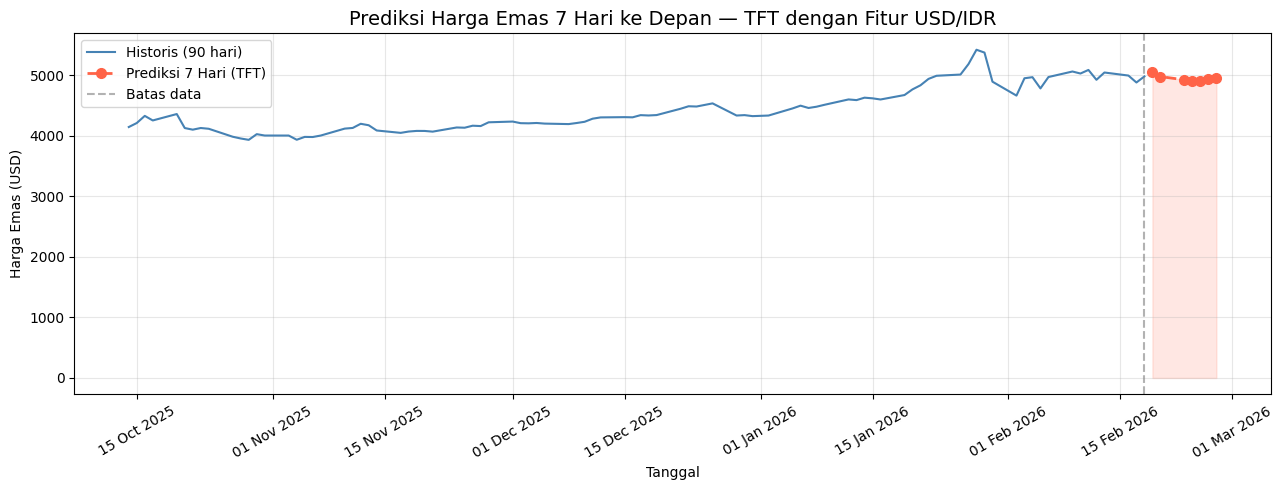


✅ Selesai!


In [ ]:
# Plot prediksi masa depan
fig, ax = plt.subplots(figsize=(13, 5))
hist_dates  = df['date'].tail(90)
hist_close  = df['close'].tail(90)
ax.plot(hist_dates, hist_close, color='steelblue', linewidth=1.5, label='Historis (90 hari)')
ax.plot(future_dates, future_values, 'o--', color='tomato', linewidth=2,
        markersize=7, label='Prediksi 7 Hari (TFT)')
ax.axvline(x=last_date, color='gray', linestyle='--', alpha=0.6, label='Batas data')
ax.fill_between(future_dates, future_values, alpha=0.15, color='tomato')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xticks(rotation=30)
ax.set_title("Prediksi Harga Emas 7 Hari ke Depan — TFT dengan Fitur USD/USD", fontsize=14)
ax.set_xlabel("Tanggal"); ax.set_ylabel("Harga Emas (USD)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("tft_future_forecast.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Selesai!")